In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

### Define the state.

In [20]:
# define the state.
class QuadraticState(TypedDict):

    a : float
    b : float
    c : float 

    equation : str
    discriminant : float
    roots : str

### Define the nodes.

In [22]:
# define the show equation node.
def show_equation(state : QuadraticState):

    equation = f'{state['a']}x^2{state['b']}x{state['c']}'

    return {
        'equation' : equation
    }

In [23]:
# define the calculate discriminant node.
def calculate_discriminant(state : QuadraticState): 

    a = state['a']
    b = state['b']
    c = state['c']

    discriminant = b**2 - 4 * a * c 

    return {
        'discriminant' : discriminant
    }

In [24]:
# define the real root node.
def real_roots(state : QuadraticState):

    a = state['a']
    b = state['b']
    d = state['discriminant']

    root1 = (-b - d**0.5) / (2 * a)
    root2 = (-b + d**0.5) / (2 * a)

    return {
        'roots' : f'The roots of the given equation is {root1} and {root2}.'
    }

In [25]:
# define the equal root node.
def equal_roots(state : QuadraticState):

    a = state['a']
    b = state['b']
    root = -b / (2 * a)

    return {
        'roots' : f'The discriminant is Zero, so both the roots are equal, root is {root}.'
    }

In [26]:
# define the node for no real root.
def no_real_roots(state : QuadraticState):

    return {
        'roots' : 'The discriminant is less than Zero, So No real roots is exist.'
    }

In [27]:
# Here we create the check condition node, where the condition is check for discriminant.
def check_condition(state : QuadraticState) -> Literal['real_roots', 'equal_roots', 'no_real_roots']:

    discriminant = state['discriminant']
    # check condition, which nodes name is return.
    if discriminant > 0: 
        return 'real_roots'
    elif discriminant == 0:
        return 'equal_roots'
    else:
        return 'no_real_roots'

In [33]:
# build the graph.
graph = StateGraph(QuadraticState)

# add the nodes in the graph.
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('equal_roots', equal_roots)
graph.add_node('no_real_roots', no_real_roots)


# add the edges in the graph.
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

# add conditional edge.
graph.add_conditional_edges('calculate_discriminant', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('equal_roots', END)
graph.add_edge('no_real_roots', END)

# compile the graph.
workflow = graph.compile()

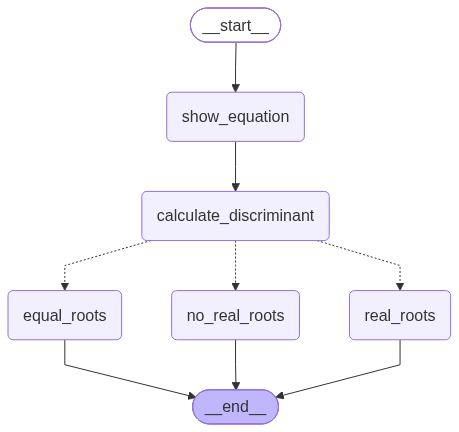

In [34]:
workflow

In [38]:
# define the initial state.
initial_state = {
    'a' : 2, 
    'b' : 4, 
    'c' : 4
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'a': 2, 'b': 4, 'c': 4, 'equation': '2x^24x4', 'discriminant': -16, 'roots': 'The discriminant is less than Zero, So No real roots is exist.'}
